8.1

In [13]:
import numpy as np
X= np.array([[1,1,1,1,1,1],[-1,-1,-1,-1,-1,-1],[1,1,-1,-1,1,1],[-1,-1,1,1,-1,-1]])
Y=np.array([[1,1,1],[-1,-1,-1],[1,-1,1],[-1,1,-1]])
W= np.dot(X.T,Y)
print("Weight Matrix:\n",W)
def activate(data):
    return np.where(data>=0,1,-1)
print("Testing A")
for i, x in enumerate(X):
    out = activate(np.dot(x,W))
    print(f"Input: {i+1}, Output: {out}")
print("testing B")
for i, y in enumerate(Y):
    out = activate(np.dot(y,W.T))
    print(f"Input: {i+1}, Output: {out}")


Weight Matrix:
 [[4 0 4]
 [4 0 4]
 [0 4 0]
 [0 4 0]
 [4 0 4]
 [4 0 4]]
Testing A
Input: 1, Output: [1 1 1]
Input: 2, Output: [-1 -1 -1]
Input: 3, Output: [ 1 -1  1]
Input: 4, Output: [-1  1 -1]
testing B
Input: 1, Output: [1 1 1 1 1 1]
Input: 2, Output: [-1 -1 -1 -1 -1 -1]
Input: 3, Output: [ 1  1 -1 -1  1  1]
Input: 4, Output: [-1 -1  1  1 -1 -1]


8.2

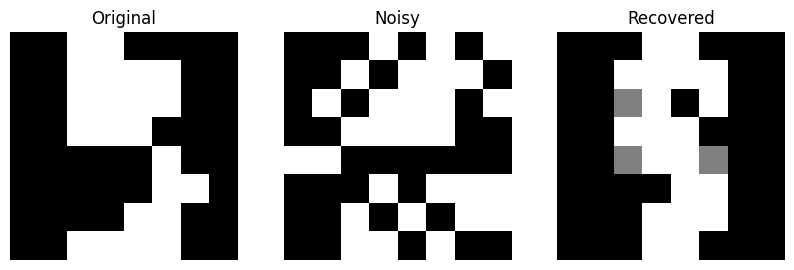

Actual Label: 5 | Predicted: 0


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
digits = load_digits()
X = np.where(digits.images.reshape(len(digits.images), -1) > 8, 1, -1)
Y = np.full((len(digits.target), 10), -1)
for i, target in enumerate(digits.target): Y[i, target] = 1
train_size = 100
W = X[:train_size].T @ Y[:train_size]
def add_noise(x, level=0.3):
    noisy = x.copy()
    idx = np.random.choice(len(x), int(len(x) * level), False)
    noisy[idx] *= -1
    return noisy
def recall(x_noisy, W, iters=5):
    x = x_noisy.copy()
    for _ in range(iters):
        y = np.sign(x @ W) # Forward to Target
        x = np.sign(y @ W.T) # Backward to Input
    return x, y
idx = 5
noisy_input = add_noise(X[idx])
rec_x, rec_y = recall(noisy_input, W)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
titles = ["Original", "Noisy", "Recovered"]
imgs = [X[idx], noisy_input, rec_x]
for i in range(3):
    ax[i].imshow(imgs[i].reshape(8,8), cmap='gray')
    ax[i].set_title(titles[i])
    ax[i].axis('off')
plt.show()
print(f"Actual Label: {digits.target[idx]} | Predicted: {np.argmax(rec_y)}")

7.1

c:\Users\jadha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


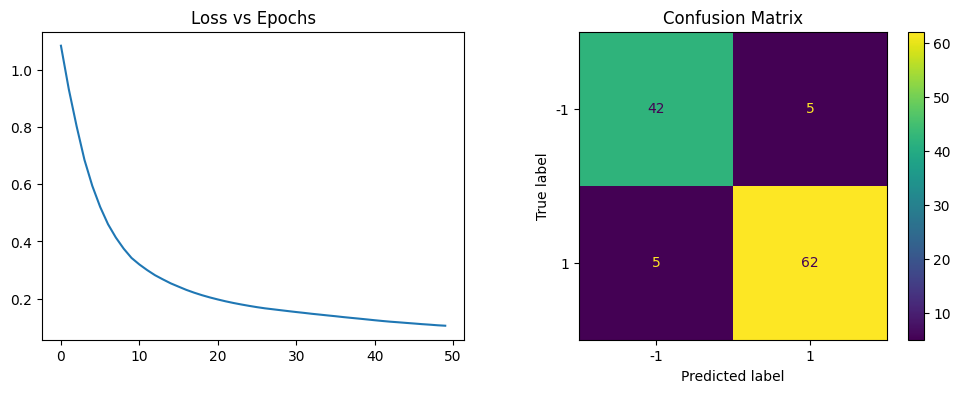

              precision    recall  f1-score   support

          -1       0.89      0.89      0.89        47
           1       0.93      0.93      0.93        67

    accuracy                           0.91       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, model_selection, preprocessing, metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
data = datasets.load_breast_cancer()
X = preprocessing.StandardScaler().fit_transform(data.data)
y = np.where(data.target == 0, -1, 1)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=0)
model = Sequential([Dense(1, input_dim=X.shape[1], activation='linear')])
model.compile(optimizer='adam', loss='hinge', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, verbose=0)
y_pred = np.where(model.predict(X_test) > 0, 1, -1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'])
ax1.set_title("Loss vs Epochs")
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax2)
ax2.set_title("Confusion Matrix")
plt.show()
print(metrics.classification_report(y_test, y_pred))

7.2

c:\Users\jadha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1673/1673 ━━━━━━━━━━━━━━━━━━━━ 1s 568us/step


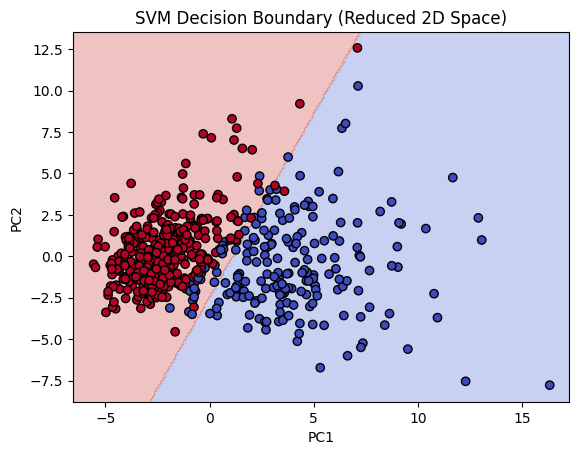

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, preprocessing, decomposition, model_selection
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
data = datasets.load_breast_cancer()
X = preprocessing.StandardScaler().fit_transform(data.data)
X_pca = decomposition.PCA(2).fit_transform(X)
y = np.where(data.target == 0, -1, 1)
model = Sequential([Dense(1, input_dim=2, activation='linear')])
model.compile(optimizer='adam', loss='hinge')
model.fit(X_pca, y, epochs=100, verbose=0)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = np.where(model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0, 1, -1).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', cmap='coolwarm')
plt.title("SVM Decision Boundary (Reduced 2D Space)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

7.3

Accuracy: 0.80
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45



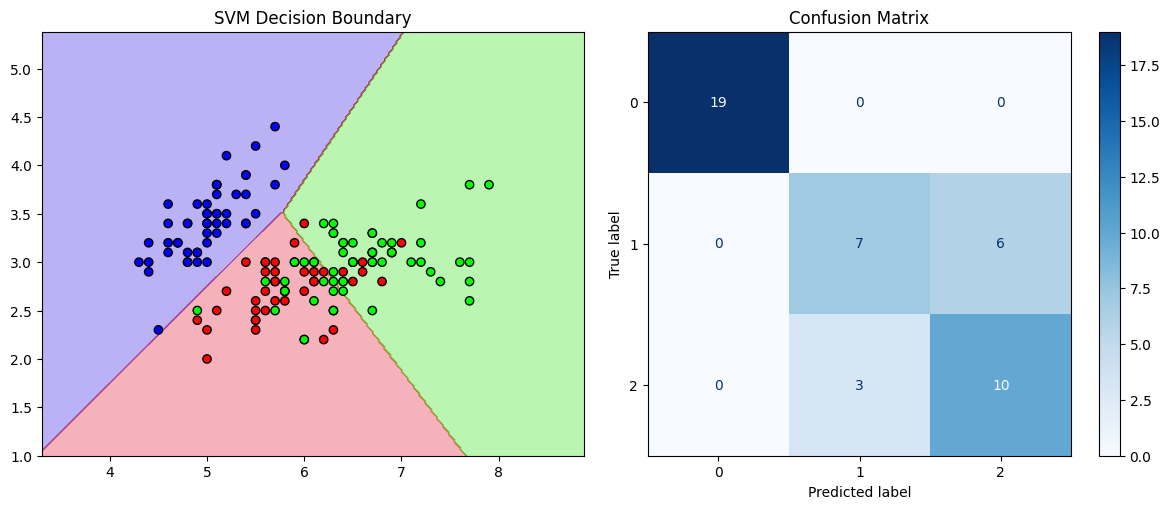

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, model_selection, svm, metrics
iris = datasets.load_iris()
X, y = iris.data[:, :2], iris.target
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)
model = svm.SVC(kernel='linear').fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[0].contourf(xx, yy, Z, alpha=0.3, cmap='brg')
ax[0].scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='brg')
ax[0].set_title("SVM Decision Boundary")
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[1], cmap='Blues')
ax[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

7.4

Accuracy: 0.9815
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        53
           1       1.00      1.00      1.00        50
           2       0.98      1.00      0.99        47
           3       1.00      0.94      0.97        54
           4       1.00      1.00      1.00        60
           5       0.98      0.98      0.98        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.91      0.98      0.94        43
           9       0.97      0.95      0.96        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



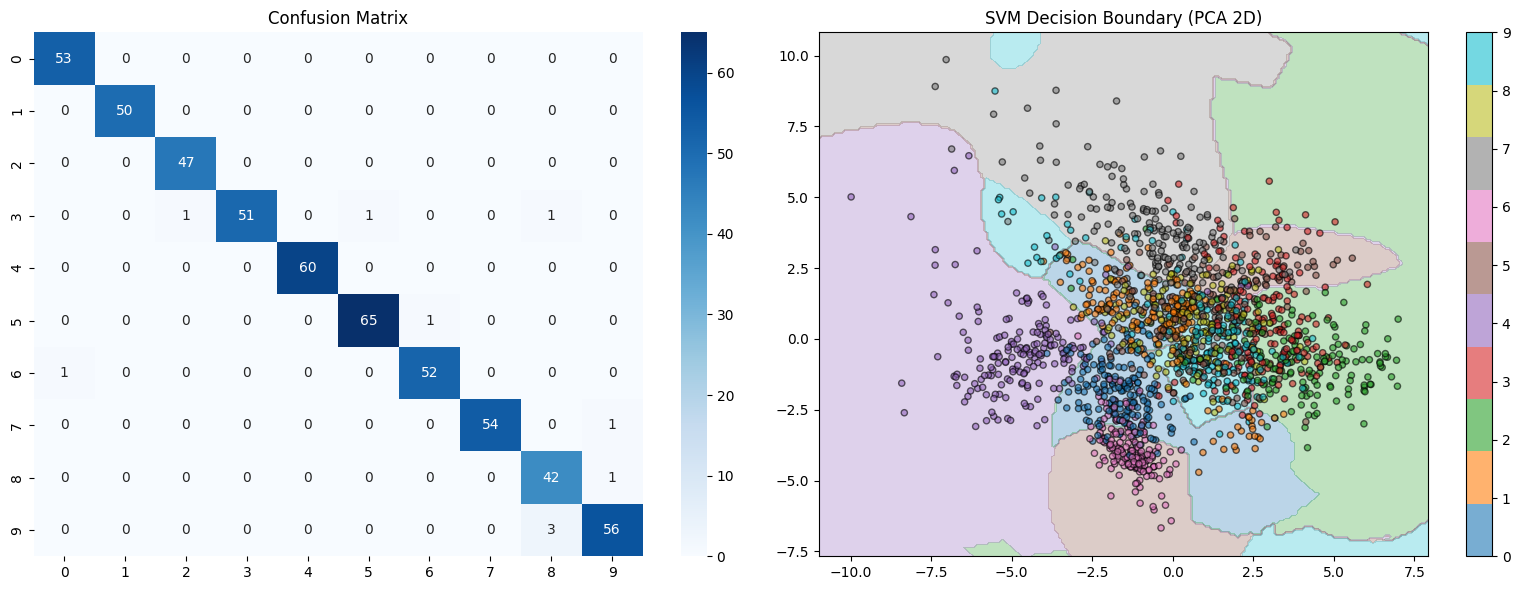

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, svm, model_selection, preprocessing, decomposition, metrics
digits = datasets.load_digits()
X = preprocessing.StandardScaler().fit_transform(digits.data)
y = digits.target
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)
clf = svm.SVC(kernel='rbf', C=10, gamma=0.001).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}")
print(metrics.classification_report(y_test, y_pred))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title("Confusion Matrix")
pca = decomposition.PCA(n_components=2)
X_pca = pca.fit_transform(X)
clf_pca = svm.SVC(kernel='rbf', C=10, gamma=0.1).fit(X_pca, y) # Visual model
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = clf_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='tab10', edgecolors='k', alpha=0.6)
ax2.set_title("SVM Decision Boundary (PCA 2D)")
plt.colorbar(scatter, ax=ax2)
plt.tight_layout()
plt.show()

6.1

Final Predictions:
 [[0.064]
 [0.941]
 [0.941]
 [0.064]]


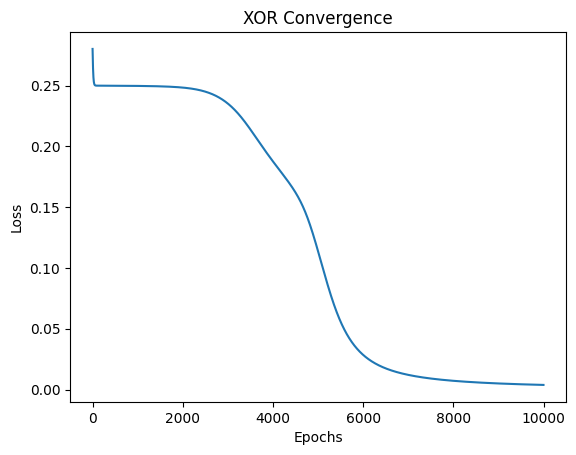

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
X, y = np.array([[0,0],[0,1],[1,0],[1,1]]), np.array([[0],[1],[1],[0]])
sigmoid = lambda x: 1 / (1 + np.exp(-x))
deriv = lambda x: x * (1 - x)
np.random.seed(1)
W1, b1 = np.random.rand(2, 2), np.random.rand(1, 2)
W2, b2 = np.random.rand(2, 1), np.random.rand(1, 1)
lr, history = 0.1, []
for _ in range(10000):
    h_out = sigmoid(X @ W1 + b1)
    o_out = sigmoid(h_out @ W2 + b2)
    history.append(np.mean((y - o_out)**2))
    d_out = (y - o_out) * deriv(o_out)
    d_hid = (d_out @ W2.T) * deriv(h_out)
    W2 += (h_out.T @ d_out) * lr
    b2 += np.sum(d_out, axis=0, keepdims=True) * lr
    W1 += (X.T @ d_hid) * lr
    b1 += np.sum(d_hid, axis=0, keepdims=True) * lr
print("Final Predictions:\n", o_out.round(3))
plt.plot(history)
plt.title("XOR Convergence"); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.show()

6.2

Prob: 0.78 | Trend: UP


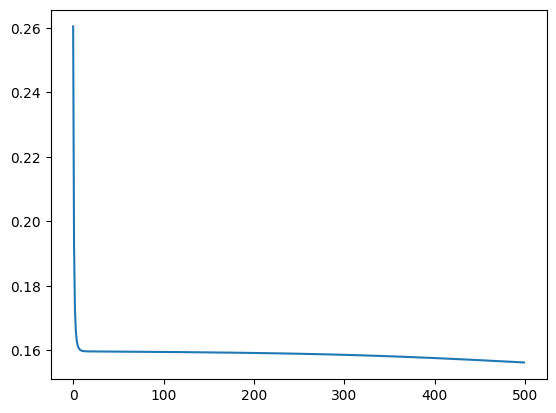

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array([[100,102,101,105,108],[102,101,105,108,110],[101,105,108,110,112],[105,108,110,112,115],[104,102,102,101,100]])
y = np.array([[1, 1, 1, 1, 0]]).T
X_n = X / X.max()
s, d = lambda x: 1/(1+np.exp(-x)), lambda x: x*(1-x)
np.random.seed(1)
W1, b1 = np.random.randn(5,4), np.zeros((1,4))
W2, b2 = np.random.randn(4,1), np.zeros((1,1))
loss = []
for _ in range(500):
    h, o = s(X_n @ W1 + b1), s(s(X_n @ W1 + b1) @ W2 + b2)
    err = y - o
    loss.append((err**2).mean())
    do = err * d(o)
    dh = (do @ W2.T) * d(h)
    W2, b2 = W2 + (h.T @ do)*0.5, b2 + do.sum(0)*0.5
    W1, b1 = W1 + (X_n.T @ dh)*0.5, b1 + dh.sum(0)*0.5
test = np.array([[104, 102, 102, 101, 100]]) / X.max()
pred = s(s(test @ W1 + b1) @ W2 + b2)
print(f"Prob: {pred[0,0]:.2f} | Trend: {'UP' if pred > 0.5 else 'DOWN'}")
plt.plot(loss); plt.show()

6.3

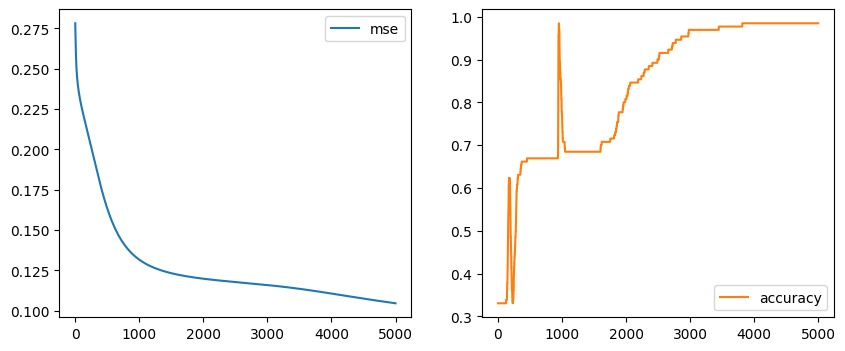

Test Accuracy: 0.95


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
X, y = iris.data, np.eye(3)[iris.target] # One-hot encode targets immediately
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=4)
np.random.seed(10)
W1, W2 = np.random.normal(0, 0.5, (4, 2)), np.random.normal(0, 0.5, (2, 3))
lr, epochs, history = 0.1, 5000, []
s = lambda x: 1 / (1 + np.exp(-x))
for i in range(epochs):
    h, o = s(X_train @ W1), s(s(X_train @ W1) @ W2)
    mse = np.mean((y_train - o)**2)
    acc = np.mean(o.argmax(1) == y_train.argmax(1))
    history.append([mse, acc])
    do = (o - y_train) * (o * (1 - o))
    dh = (do @ W2.T) * (h * (1 - h))
    W2 -= lr * (h.T @ do) / len(y_train)
    W1 -= lr * (X_train.T @ dh) / len(y_train)
res = pd.DataFrame(history, columns=['mse', 'accuracy'])
res.plot(subplots=True, layout=(1,2), figsize=(10,4))
plt.show()
test_out = s(s(X_test @ W1) @ W2)
print(f"Test Accuracy: {np.mean(test_out.argmax(1) == y_test.argmax(1)):.2f}")

4


--- OR Gate ---
[0 0]: 0
[0 1]: 1
[1 0]: 1
[1 1]: 1


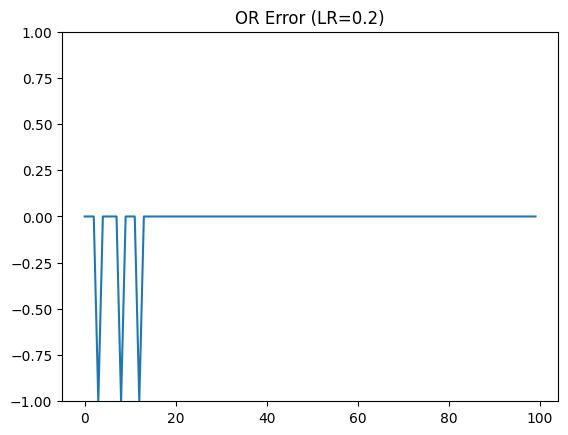


--- AND Gate ---
[0 0]: 0
[0 1]: 0
[1 0]: 0
[1 1]: 1


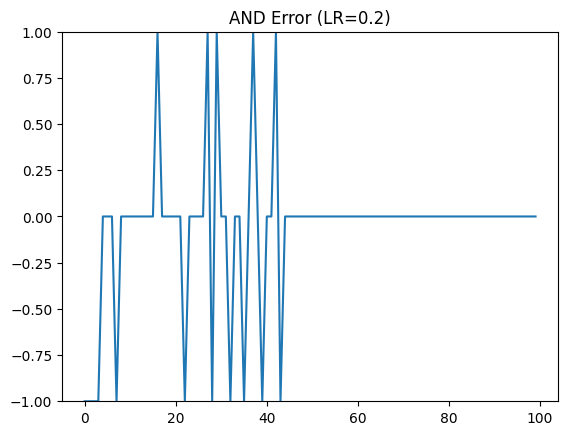


--- NOR Gate ---
[0 0]: 1
[0 1]: 0
[1 0]: 0
[1 1]: 0


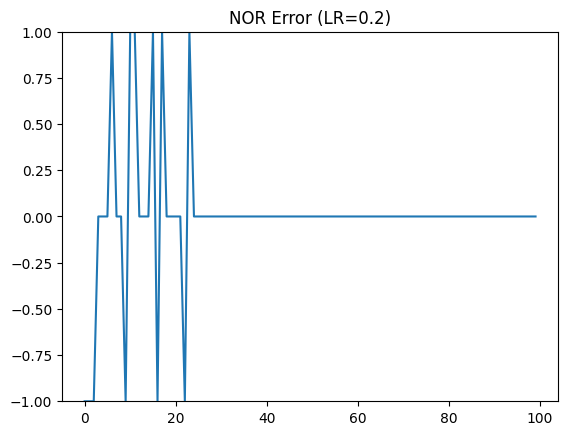


--- NAND Gate ---
[0 0]: 1
[0 1]: 1
[1 0]: 1
[1 1]: 0


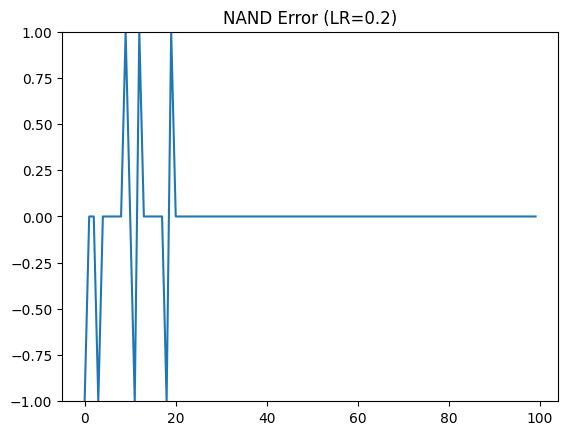


--- XOR Gate ---
[0 0]: 1
[0 1]: 1
[1 0]: 1
[1 1]: 1


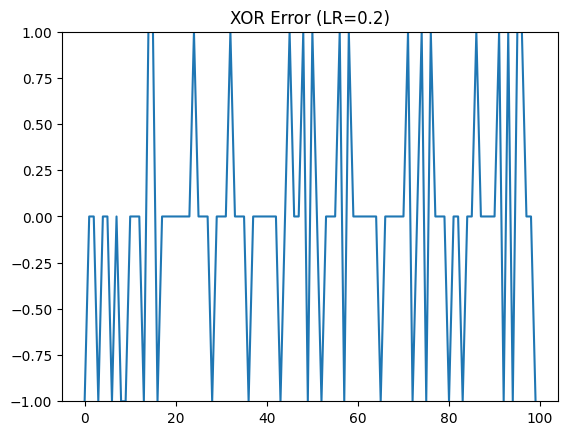

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def train_perceptron(gate_name, dataset, lr=0.2, n=100):
    weights = np.random.rand(3)
    errors = []
    
    for _ in range(n):
        x, expected = dataset[np.random.randint(len(dataset))]
        result = 1 if np.dot(weights, x) >= 0 else 0
        err = expected - result
        errors.append(err)
        weights += lr * err * x

    print(f"\n--- {gate_name} Gate ---")
    for x, _ in dataset:
        res = 1 if np.dot(weights, x) >= 0 else 0
        print(f"{x[:2]}: {res}")
    
    plt.plot(errors); plt.title(f"{gate_name} Error (LR={lr})"); plt.ylim([-1,1]); plt.show()

# Datasets [x1, x2, bias]
OR =  [(np.array([0,0,1]), 0), (np.array([0,1,1]), 1), (np.array([1,0,1]), 1), (np.array([1,1,1]), 1)]
AND = [(np.array([0,0,1]), 0), (np.array([0,1,1]), 0), (np.array([1,0,1]), 0), (np.array([1,1,1]), 1)]
NOR = [(np.array([0,0,1]), 1), (np.array([0,1,1]), 0), (np.array([1,0,1]), 0), (np.array([1,1,1]), 0)]
NAND=[(np.array([0,0,1]), 1), (np.array([0,1,1]), 1), (np.array([1,0,1]), 1), (np.array([1,1,1]), 0)]
XOR = [(np.array([0,0,1]), 0), (np.array([0,1,1]), 1), (np.array([1,0,1]), 1), (np.array([1,1,1]), 0)]

# Run Tasks
for gate, data in [("OR", OR), ("AND", AND), ("NOR", NOR), ("NAND", NAND), ("XOR", XOR)]:
    train_perceptron(gate, data)

1

Epoch 1
Inputs: [0 0] Output: 0 Predicted Output: 0.71 Error: -0.71 Trained Weights: 0.3 0.58 Trained Bias: 0.81
Inputs: [0 1] Output: 0 Predicted Output: 0.8 Error: -0.8 Trained Weights: 0.3 0.5 Trained Bias: 0.73
Inputs: [1 0] Output: 0 Predicted Output: 0.74 Error: -0.74 Trained Weights: 0.23 0.5 Trained Bias: 0.65
Inputs: [1 1] Output: 1 Predicted Output: 0.8 Error: 0.2 Trained Weights: 0.25 0.52 Trained Bias: 0.67
Epoch 2
Inputs: [0 0] Output: 0 Predicted Output: 0.66 Error: -0.66 Trained Weights: 0.25 0.52 Trained Bias: 0.61
Inputs: [0 1] Output: 0 Predicted Output: 0.76 Error: -0.76 Trained Weights: 0.25 0.45 Trained Bias: 0.53
Inputs: [1 0] Output: 0 Predicted Output: 0.69 Error: -0.69 Trained Weights: 0.18 0.45 Trained Bias: 0.46
Inputs: [1 1] Output: 1 Predicted Output: 0.75 Error: 0.25 Trained Weights: 0.21 0.47 Trained Bias: 0.49
Epoch 3
Inputs: [0 0] Output: 0 Predicted Output: 0.62 Error: -0.62 Trained Weights: 0.21 0.47 Trained Bias: 0.43
Inputs: [0 1] Output: 0 Predicte

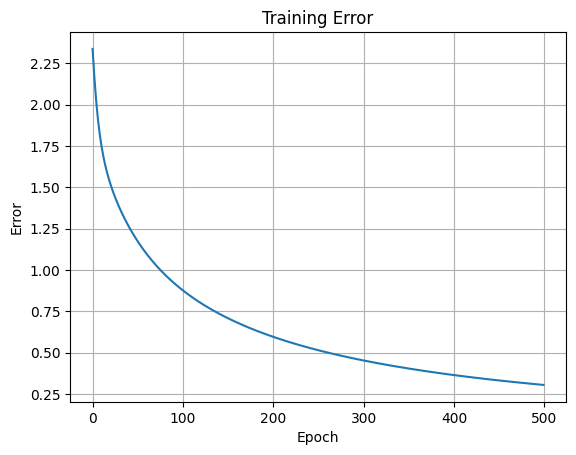

In [29]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0, 0, 0, 1])
weights = np.random.rand(2)
bias = np.random.rand()
lr = 0.1
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
errors = []
for epoch in range(500):
    print(f"Epoch {epoch+1}")
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        y_pred = sigmoid(z)
        error = y[i] - y_pred
        # Weight update
        weights += lr * error * X[i]
        bias += lr * error
        print("Inputs:",X[i], "Output:",y[i],"Predicted Output:",round(y_pred,2),"Error:", round(error,2), "Trained Weights:",round(weights[0],2), round(weights[1],2),"Trained Bias:",round(bias,2))
    total_error = 0
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        y_pred = sigmoid(z)
        total_error += abs(y[i] - y_pred)
    errors.append(total_error)
plt.plot(errors)
plt.title("Training Error")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.grid()
plt.show()

2


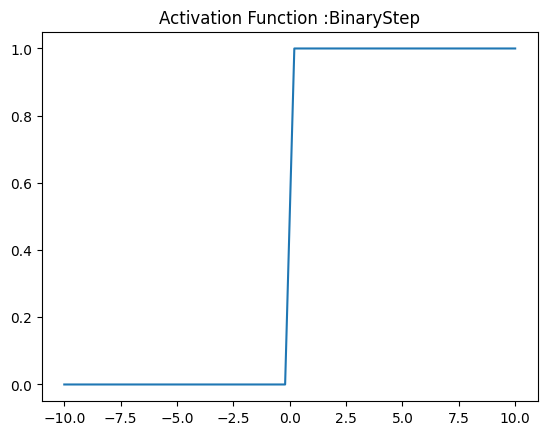

Example: Simple Decision making-Pass or Fail system
Marks Input: [-2 -1  0  1  3]
Pass(1)/Fail(0): [0 0 1 1 1]


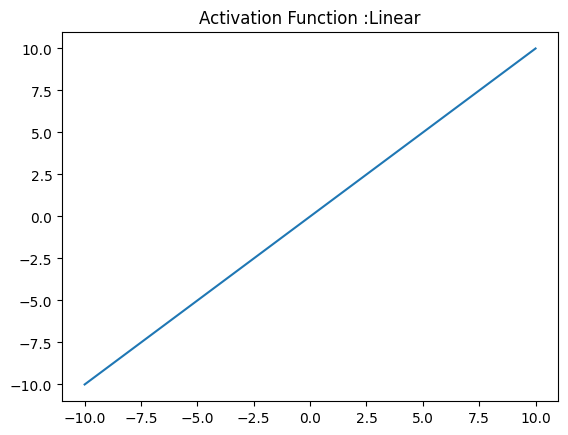

Example: House Price Prediction
area: 1200
rate: 5000
Predicted House Price: 6000000


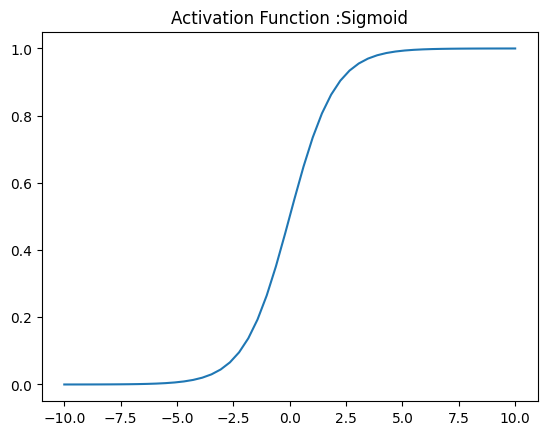

Example: Disease Detection: Yes/No (Binary Classification)
 Disease Probability: 0.7685247834990175
Patient: POSITIVE


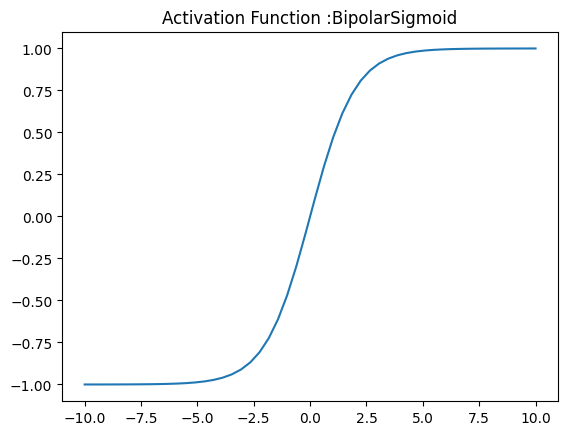

Example: Pattern Recognition (Signal Classification)
Input: [-2 -1  0  1  2]
Output: [8.3890561  3.71828183 2.         1.36787944 1.13533528]


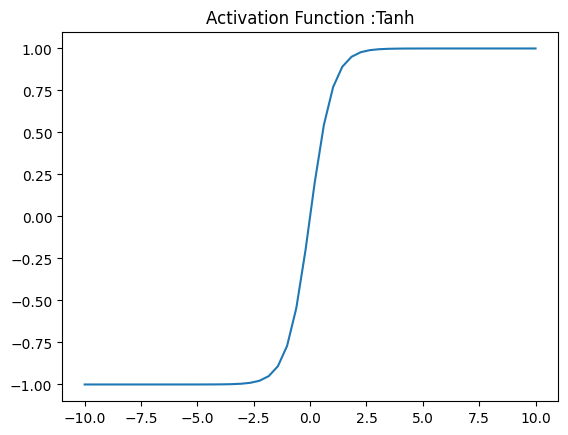

Example: Feature Normalization in NLP/Deep Learning
Input: [-3 -1  0  1  3]
Tanh Output: [-0.99505475 -0.76159416  0.          0.76159416  0.99505475]


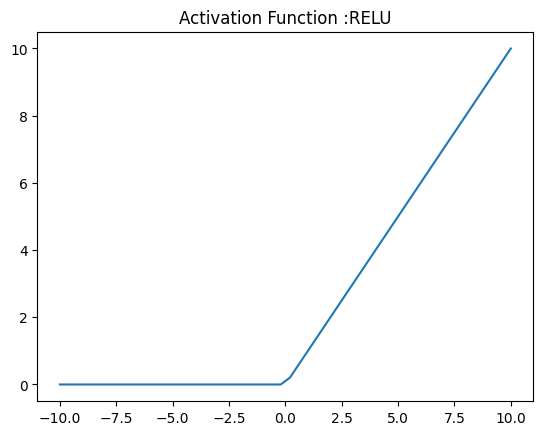

Example: Image Processing- Feature Extraction in CNN
Pixel Input: [-120  -30    0   80  150]
Relu Output: [  0   0   0  80 150]


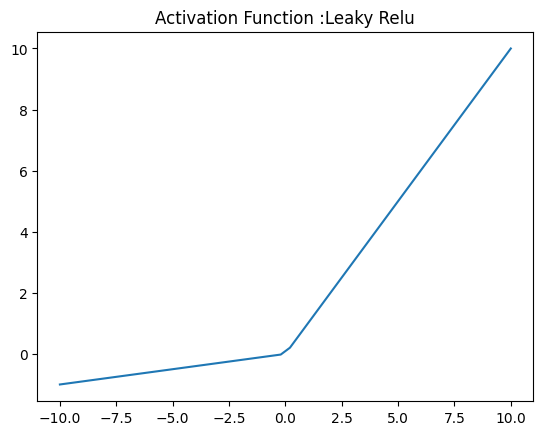

Example: GAN Training Avoid Dead Neurons
Input: [-5 -2 -1  0  2  4]
Leaky Relu Output: [-0.05 -0.02 -0.01  0.    2.    4.  ]


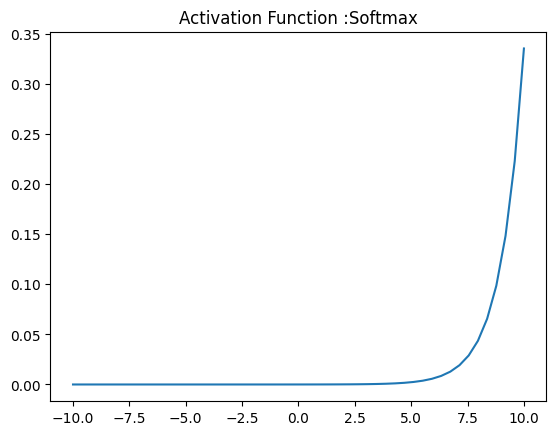

Example: Multiclass Classification-Emotion Detection
Emotion Probabilities: [0.60561081 0.27211848 0.12227071]
Predicted Emotion Class: 0


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
def binaryStep(x):
    ''' It returns '0' is the input is less then zero otherwise it returns one '''
    return np.heaviside(x,1)
x = np.linspace(-10, 10)
plt.plot(x, binaryStep(x))
plt.axis('tight')
plt.title('Activation Function :BinaryStep')
plt.show()
print("Example: Simple Decision making-Pass or Fail system")
def binary_step (x):
    return np.where (x >= 0, 1, 0)
marks=np.array ([-2, -1, 0, 1, 3])
results=binary_step(marks)
print("Marks Input:", marks)
print("Pass(1)/Fail(0):", results)
def linear(x):
    ''' y = f(x) It returns the input as it is'''
    return x
x = np.linspace(-10, 10)
plt.plot(x, linear(x))
plt.axis('tight')
plt.title('Activation Function :Linear')
plt.show()
print("Example: House Price Prediction")
def linear(x):
    return x
area= 1200 
rate=5000 
price= linear(area*rate)
print("area:", area)
print("rate:", rate)
print("Predicted House Price:", price)
def sigmoid(x):
    ''' It returns 1/(1+exp(-x)). where the values lies between zero and one '''
    return 1/(1+np.exp(-x))
x = np.linspace(-10, 10)
plt.plot(x, sigmoid(x))
plt.axis('tight')
plt.title('Activation Function :Sigmoid')
plt.show()
print("Example: Disease Detection: Yes/No (Binary Classification)")
import numpy as np
def sigmoid(x):
    return 1/(1+np.exp(-x))
z=1.2 #weighted sum
prob=sigmoid(z)
print(" Disease Probability:", prob)
if prob >=0.5:
    print("Patient: POSITIVE")
else:
    print("Patient:NEGATIVE")
def bipolarsigmoid(x):
    ''' It returns -1+2/(1+exp(-x)). where the values lies between zero and one '''
    return -1+2/(1+np.exp(-x))
x = np.linspace(-10, 10)
plt.plot(x, bipolarsigmoid(x))
plt.axis('tight')
plt.title('Activation Function :BipolarSigmoid')
plt.show()
print("Example: Pattern Recognition (Signal Classification)")
import numpy as np
def bipolar_sigmoid(x):
    return -1+2/1+np.exp(-x)
x=np.array([-2, -1, 0, 1, 2])
y=bipolar_sigmoid(x)
print("Input:", x)
print("Output:", y)
def tanh(x):
    ''' It returns the value (1-exp(-2x))/(1+exp(-2x)) and the value returned will be lies in between -1 to
1.'''
    return np.tanh(x)
x = np.linspace(-10, 10)
plt.plot(x, tanh(x))
plt.axis('tight')
plt.title('Activation Function :Tanh')
plt.show()
print("Example: Feature Normalization in NLP/Deep Learning")
import numpy as np
x=np.array([-3, -1, 0, 1, 3])
y=np.tanh(x)
print("Input:", x)
print("Tanh Output:", y)
def RELU(x):
    ''' It returns zero if the input is less than zero otherwise it returns the given input. '''
    x1=[]
    for i in x:
        if i<0:
            x1.append(0)
        else:
            x1.append(i)
    return x1
x = np.linspace(-10, 10)
plt.plot(x, RELU(x))
plt.axis('tight')
plt.title('Activation Function :RELU')
plt.show()
print("Example: Image Processing- Feature Extraction in CNN")
import numpy as np
def relu (x):
    return np.maximum(0, x)
pixel_values=np.array([-120, -30, 0, 80, 150])
output=relu (pixel_values)
print("Pixel Input:", pixel_values)
print("Relu Output:", output)
def leaky_relu(x):
    alpha = 0.1
    return np.maximum(alpha*x, x)
x = np.linspace(-10, 10)
plt.plot(x, leaky_relu(x))
plt.axis('tight')
plt.title('Activation Function :Leaky Relu')
plt.show()
print ("Example: GAN Training Avoid Dead Neurons")
import numpy as np
def leaky_relu(x, alpha=0.01):
    return np.where(x>0, x, alpha*x)
x=np.array([-5, -2, -1, 0, 2, 4])
y=leaky_relu(x)
print("Input:", x)
print("Leaky Relu Output:", y)
# Softmax Activation Function
def softmax(x):
    ''' Compute softmax values for each sets of scores in x. '''
    return np.exp(x) / np.sum(np.exp(x), axis=0)
x = np.linspace(-10, 10)
plt.plot(x, softmax(x))
plt.axis('tight')
plt.title('Activation Function :Softmax')
plt.show()
print("Example: Multiclass Classification-Emotion Detection")
import numpy as np
def softmax(x):
    exp_x=np.exp(x-np.max(x))
    return exp_x/np.sum(exp_x)
scores=np.array([2.1, 1.3, 0.5])
prob=softmax(scores)
print("Emotion Probabilities:", prob)
print("Predicted Emotion Class:", np.argmax(prob))